# Lab 14 - Design a Better Policy Dataset

**Goal:** turn the Lab 13 diagnosis into a controlled Dataset B without modifying Dataset A.

Lab 13 showed that the model was mostly trained to finish Wordle, not play Wordle:

- `NEXT_GUESS` was 11.4% of train examples and 10.6% of train tokens;
- 88.3% of train policy examples had only 1-2 candidates;
- train had no policy states with 51+ candidates and only 12 with 11-50;
- each history received one policy label but about 7.17 auxiliary examples.

The hypothesis is now specific:

> Gameplay is weak because direct policy supervision is scarce, especially for early high-uncertainty states and later states combining long histories with nontrivial candidate sets.

## 14.1 Two design components

Dataset B changes two things for two different reasons.

### Lever 1: reweight existing states

- preserve complete canonical teacher trajectories;
- let repeated state visits represent how often answers encounter a state;
- cap auxiliary expansion at one example per unique history;
- omit the shared no-history state so neither corpus trains on the reserved gameplay path;

### Lever 2: create missing strategic states

- force several legal, controlled opening guesses;
- ask the symbolic teacher for the next action after that opening;
- retain unique turn-2 states with at least 11 candidates;
- retain unique turn-3+ states with at least 3 candidates.

Generating more games from the same deterministic opening would reproduce the same decision tree. Alternative legal openings create states that tree does not expose.

The current benchmark asks the model to generate turn 1. Lab 15 will instead seed the same fixed `RAISE` opening for both models, then evaluate learned policy from turn 2 onward. That keeps opening treatment identical while this experiment tests the post-opening dataset hypothesis.

## 14.2 Experimental contract

To keep Lab 15 interpretable:

- Dataset A remains the exact persisted Lab 06 corpus;
- Dataset B keeps the same prompt and response representation;
- the symbolic expert and answer lexicon remain fixed;
- fixed gameplay test answers are excluded from Dataset B metadata;
- all examples sharing an underlying history stay in one data split;
- every generated row records its source.

The new task proportions are outcomes of these rules, not hand-picked percentages.

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiny_wordle.expert import EntropyExpert
from tiny_wordle.game import Turn, score_string

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("../data")
GENERATED_DIR = DATA_DIR / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
]
PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")

assert len(ANSWERS) == 2315
assert PATTERNS.shape == (2315, 2315)

expert = EntropyExpert(ANSWERS, PATTERNS)
WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print("answers:", len(ANSWERS))
print("pattern matrix:", PATTERNS.shape)

answers: 2315
pattern matrix: (2315, 2315)


## 14.3 Load Dataset A as the immutable control

We load and fingerprint the existing files. This notebook never writes to their paths.

In [2]:
A_PATHS = {
    "train": GENERATED_DIR / "wordle-sft-train.jsonl",
    "dev": GENERATED_DIR / "wordle-sft-dev.jsonl",
    "test": GENERATED_DIR / "wordle-sft-test.jsonl",
}

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

a_hashes_before = {split: sha256_file(path) for split, path in A_PATHS.items()}
dataset_a = pd.concat(
    [pd.read_json(path, lines=True) for path in A_PATHS.values()],
    ignore_index=True,
)

print("Dataset A rows:", len(dataset_a))
display(pd.crosstab(dataset_a["split"], dataset_a["task"]))
display(pd.Series(a_hashes_before, name="sha256"))

Dataset A rows: 18824


task,CHOOSE_VALID,NEXT_GUESS,VALID_CANDIDATE
split,,,
dev,602,385,1182
test,49,43,98
train,5353,1876,9236


train    e54bb9cd2f17c2aef3ae0b6c835c987528525dac722a9b...
dev      e241f2e9918058a7f7653c977c8314e01b792a0af3069d...
test     986b15b8094d40ef24251ea4b10363ede6b202b3053c64...
Name: sha256, dtype: str

## 14.4 Reserve gameplay evaluation answers

These answers stay out of Dataset B metadata. Lab 15 will still evaluate complete games on them. Dataset B itself uses state-grouped splits because the model-facing state, not hidden answer metadata, determines the expert action.

In [3]:
FIXED_GAMEPLAY_TEST_ANSWERS = {
    "SHORE", "MIGHT", "BRICK", "GHOST", "KNIFE",
    "DOUBT", "FLING", "ROUND", "CHAMP", "WASTE",
    "BLIND", "POINT", "SLATE", "CRANE", "APPLE",
    "SHEEP", "BANAL", "ALLEY", "AUDIO",
}

DEVELOPMENT_ANSWERS = [
    answer for answer in ANSWERS
    if answer not in FIXED_GAMEPLAY_TEST_ANSWERS
]

assert FIXED_GAMEPLAY_TEST_ANSWERS <= set(ANSWERS)
assert set(DEVELOPMENT_ANSWERS).isdisjoint(FIXED_GAMEPLAY_TEST_ANSWERS)
print("development answers:", len(DEVELOPMENT_ANSWERS))
print("reserved gameplay answers:", len(FIXED_GAMEPLAY_TEST_ANSWERS))

development answers: 2296
reserved gameplay answers: 19


## 14.5 Rebuild teacher trajectories

The cache avoids rescoring the same candidate set for every answer that visits it. It does not change the expert policy.

In [4]:
@dataclass(frozen=True)
class PolicyState:
    answer: str
    source: str
    opening: str
    turn: int
    history: tuple[Turn, ...]
    candidate_indices: tuple[int, ...]
    expert_guess: str

choice_cache: dict[tuple[int, ...], int] = {}

def choose_cached(candidate_indices: np.ndarray) -> int:
    key = tuple(int(index) for index in candidate_indices)
    if key not in choice_cache:
        choice_cache[key] = expert.choose(candidate_indices)
    return choice_cache[key]

def play_teacher_trajectory(
    answer: str,
    forced_opening: str | None = None,
    max_turns: int = 6,
) -> tuple[list[PolicyState], bool]:
    candidates = ALL_INDICES.copy()
    history: list[Turn] = []
    states: list[PolicyState] = []

    if forced_opening is not None:
        opening_idx = WORD_TO_INDEX[forced_opening]
        feedback = score_string(answer, forced_opening)
        history.append(Turn(guess=forced_opening, feedback=feedback))
        if feedback == "GGGGG":
            return states, True
        candidates = expert.update(candidates, opening_idx, feedback)
        start_turn = 2
        source = f"alternative_{forced_opening}"
        opening = forced_opening
    else:
        start_turn = 1
        source = "canonical_trajectory"
        opening = "EXPERT"

    for turn in range(start_turn, max_turns + 1):
        guess_idx = choose_cached(candidates)
        guess = ANSWERS[guess_idx]
        states.append(PolicyState(
            answer=answer,
            source=source,
            opening=opening,
            turn=turn,
            history=tuple(history),
            candidate_indices=tuple(int(index) for index in candidates),
            expert_guess=guess,
        ))

        feedback = score_string(answer, guess)
        history.append(Turn(guess=guess, feedback=feedback))
        if feedback == "GGGGG":
            return states, True

        candidates = expert.update(candidates, guess_idx, feedback)
        if len(candidates) == 0:
            raise RuntimeError(f"candidate set became empty for {answer}")

    return states, False

## 14.6 Lever 1: preserve canonical trajectory visits

We retain every turn 2-6 state from each solved development trajectory. Repeated prompts are intentional visitation weights. Every state on a reserved gameplay answer's canonical expert path is excluded from Dataset B, matching Dataset A's train boundary. This includes the no-history state, so Lab 15 must seed the same fixed opening for both models.

In [5]:
canonical_trajectories: dict[str, list[PolicyState]] = {}
canonical_failures = []
evaluation_trajectories = {}
evaluation_failures = []

for answer in sorted(FIXED_GAMEPLAY_TEST_ANSWERS):
    states, solved = play_teacher_trajectory(answer)
    evaluation_trajectories[answer] = states
    if not solved:
        evaluation_failures.append(answer)

EVALUATION_HISTORIES = {
    state.history
    for states in evaluation_trajectories.values()
    for state in states
}

for answer in DEVELOPMENT_ANSWERS:
    states, solved = play_teacher_trajectory(answer)
    if solved:
        canonical_trajectories[answer] = states
    else:
        canonical_failures.append(answer)

canonical_policy_states = [
    state
    for states in canonical_trajectories.values()
    for state in states
    if state.turn > 1 and state.history not in EVALUATION_HISTORIES
]

print("solved canonical trajectories:", len(canonical_trajectories))
print("failed canonical trajectories:", len(canonical_failures))
print("failed reserved trajectories:", evaluation_failures)
print("reserved evaluation states:", len(EVALUATION_HISTORIES))
print("canonical policy visits:", len(canonical_policy_states))
print("choice-cache states:", len(choice_cache))

solved canonical trajectories: 2286
failed canonical trajectories: 10
failed reserved trajectories: ['WASTE']
reserved evaluation states: 48
canonical policy visits: 5034
choice-cache states: 2304


## 14.7 Lever 2: create missing high-uncertainty states

The four openings intentionally expose different letter profiles:

- `STARE`: common consonants and vowels;
- `MOUND`: rounded vowels with different consonants;
- `GLYPH`: consonant-heavy and `Y`;
- `FJORD`: uncommon consonants with `O`.

For every development answer, we force one opening and let the teacher finish the trajectory. We retain one row per newly exposed history when either:

- turn 2 still has at least 11 candidates; or
- turn 3 or later still has at least 3 candidates.

Canonical trajectories carry realistic visitation weight. Alternative trajectories contribute state diversity, so repeated hypothetical visits are deduplicated rather than allowed to dominate Dataset B.

In [6]:
ALTERNATIVE_OPENINGS = ["STARE", "MOUND", "GLYPH", "FJORD"]
MIN_EARLY_CANDIDATES = 11
MIN_DEEP_CANDIDATES = 3
MIN_DEEP_TURN = 3

assert set(ALTERNATIVE_OPENINGS) <= set(ANSWERS)
assert set(ALTERNATIVE_OPENINGS).isdisjoint(FIXED_GAMEPLAY_TEST_ANSWERS)
assert len({letter for word in ALTERNATIVE_OPENINGS for letter in word}) >= 15

alternative_policy_states: list[PolicyState] = []
alternative_summary_rows = []

for opening in ALTERNATIVE_OPENINGS:
    retained_by_history: dict[tuple[Turn, ...], PolicyState] = {}
    solved_trajectories = 0
    unsolved_trajectories = 0
    early_visits = 0
    deep_visits = 0
    for answer in DEVELOPMENT_ANSWERS:
        states, solved = play_teacher_trajectory(answer, forced_opening=opening)
        solved_trajectories += int(solved)
        unsolved_trajectories += int(not solved)
        for state in states:
            candidate_count = len(state.candidate_indices)
            is_early = state.turn == 2 and candidate_count >= MIN_EARLY_CANDIDATES
            is_deep = state.turn >= MIN_DEEP_TURN and candidate_count >= MIN_DEEP_CANDIDATES
            if is_early:
                early_visits += 1
            if is_deep:
                deep_visits += 1
            if (is_early or is_deep) and state.history not in EVALUATION_HISTORIES:
                retained_by_history.setdefault(state.history, state)

    retained_states = list(retained_by_history.values())
    alternative_policy_states.extend(retained_states)
    alternative_summary_rows.append({
        "opening": opening,
        "solved_trajectories": solved_trajectories,
        "unsolved_trajectories": unsolved_trajectories,
        "eligible_early_visits": early_visits,
        "eligible_deep_visits": deep_visits,
        "unique_early_states": len({
            state.history for state in retained_states if state.turn == 2
        }),
        "unique_deep_states": len({
            state.history for state in retained_states if state.turn >= MIN_DEEP_TURN
        }),
        "retained_unique_states": len(retained_states),
    })

alternative_summary = pd.DataFrame(alternative_summary_rows)
display(alternative_summary)
print("retained alternative unique states:", len(alternative_policy_states))

,opening,solved_trajectories,unsolved_trajectories,eligible_early_visits,eligible_deep_visits,unique_early_states,unique_deep_states,retained_unique_states
0,STARE,2286,10,1951,1409,48,307,355
1,MOUND,2291,5,2098,1648,29,295,324
2,GLYPH,2291,5,2157,1787,25,283,308
3,FJORD,2284,12,2156,1919,21,309,330


retained alternative unique states: 1317


## 14.8 Keep state groups together

Dataset A used answer-level splits followed by held-out-priority deduplication. That moved shared early policy states out of train. Dataset B groups each trajectory branch by its first guess and feedback, then hashes that root. Every parent, descendant, repeated visit, and auxiliary task in the branch stays in one split.

The 88/11/1 thresholds approximate Dataset A's train/dev/test proportions. The fixed gameplay answer set remains a separate end-to-end evaluation boundary.

In [7]:
def format_history(history: tuple[Turn, ...] | list[Turn]) -> str:
    if not history:
        return "No previous guesses."
    return "\n".join(
        f"{' '.join(turn.guess)} -> {' '.join(turn.feedback)}"
        for turn in history
    )

def stable_bucket(value: str) -> int:
    digest = hashlib.sha256(value.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

def state_group_key(history_key: str) -> str:
    if history_key == "No previous guesses.":
        return history_key
    return history_key.splitlines()[0]

def state_split(history_key: str) -> str:
    bucket = stable_bucket("dataset-b-branch:" + state_group_key(history_key))
    if bucket < 10:
        return "test"
    if bucket < 120:
        return "dev"
    return "train"

def next_guess_prompt(history_key: str) -> str:
    return (
        "Task: NEXT_GUESS\n"
        "You are playing Wordle.\n"
        "Use the game history to choose the next guess.\n"
        "Return exactly one uppercase five-letter word.\n\n"
        "History:\n"
        f"{history_key}"
    )

all_policy_states = canonical_policy_states + alternative_policy_states

def policy_row(state: PolicyState) -> dict:
    history_key = format_history(state.history)
    return {
        "task": "NEXT_GUESS",
        "split": state_split(history_key),
        "source": state.source,
        "opening": state.opening,
        "answer": state.answer,
        "turn": state.turn,
        "candidate_count": len(state.candidate_indices),
        "state_key": history_key,
        "prompt": next_guess_prompt(history_key),
        "response": state.expert_guess,
    }

policy_rows = [policy_row(state) for state in all_policy_states]
policy_df = pd.DataFrame(policy_rows)

state_target_counts = policy_df.groupby("state_key")["response"].nunique()
assert state_target_counts.max() == 1
print("policy visits:", len(policy_df))
print("unique policy states:", policy_df["state_key"].nunique())
display(pd.crosstab(policy_df["split"], policy_df["source"]))

policy visits: 6351
unique policy states: 3573


source,alternative_FJORD,alternative_GLYPH,alternative_MOUND,alternative_STARE,canonical_trajectory
split,,,,,
dev,15,127,113,43,371
test,0,0,0,1,12
train,315,181,211,311,4651


## 14.9 Cap auxiliary expansion by state

Each unique non-opening history receives at most one auxiliary example. A stable hash alternates between validity and two-option choice tasks; validity labels are also deterministically balanced. This rule makes policy primary without choosing a target percentage.

In [8]:
representative_states: dict[str, PolicyState] = {}
for state in all_policy_states:
    key = format_history(state.history)
    representative_states.setdefault(key, state)

def deterministic_negative(valid_indices: set[int], seed: str) -> str:
    start = stable_bucket(seed) % len(ANSWERS)
    for offset in range(len(ANSWERS)):
        index = (start + offset) % len(ANSWERS)
        if index not in valid_indices:
            return ANSWERS[index]
    raise RuntimeError("no invalid candidate exists")

def make_auxiliary_row(state: PolicyState) -> dict:
    history_key = format_history(state.history)
    valid_indices = set(state.candidate_indices)
    positive_index = state.candidate_indices[
        stable_bucket("positive:" + history_key) % len(state.candidate_indices)
    ]
    positive = ANSWERS[positive_index]
    negative = deterministic_negative(valid_indices, "negative:" + history_key)
    common = {
        "split": state_split(history_key),
        "source": "auxiliary_cap",
        "opening": state.opening,
        "answer": None,
        "turn": state.turn,
        "candidate_count": len(state.candidate_indices),
        "state_key": history_key,
    }

    if stable_bucket("aux-task:" + history_key) % 2 == 0:
        use_positive = stable_bucket("validity-label:" + history_key) % 2 == 0
        candidate = positive if use_positive else negative
        return {
            **common,
            "task": "VALID_CANDIDATE",
            "prompt": (
                "Task: VALID_CANDIDATE\n"
                "You are playing Wordle.\n"
                "Given the game history, decide whether the candidate "
                "could still be the hidden answer.\n"
                "Return exactly VALID or INVALID.\n\n"
                "History:\n"
                f"{history_key}\n\n"
                f"Candidate: {' '.join(candidate)}"
            ),
            "response": "VALID" if use_positive else "INVALID",
        }

    positive_first = stable_bucket("option-order:" + history_key) % 2 == 0
    option_a, option_b = (
        (positive, negative) if positive_first else (negative, positive)
    )
    return {
        **common,
        "task": "CHOOSE_VALID",
        "prompt": (
            "Task: CHOOSE_VALID\n"
            "You are playing Wordle.\n"
            "Exactly one option is consistent with all previous feedback.\n"
            "Return exactly the valid five-letter word.\n\n"
            "History:\n"
            f"{history_key}\n\n"
            f"Option A: {' '.join(option_a)}\n"
            f"Option B: {' '.join(option_b)}"
        ),
        "response": positive,
    }

auxiliary_rows = [
    make_auxiliary_row(state)
    for key, state in representative_states.items()
    if key != "No previous guesses."
]

auxiliary_df = pd.DataFrame(auxiliary_rows)
assert auxiliary_df.groupby("state_key").size().max() == 1
print("auxiliary examples:", len(auxiliary_df))
display(auxiliary_df["task"].value_counts())
display(auxiliary_df.loc[
    auxiliary_df["task"] == "VALID_CANDIDATE", "response"
].value_counts())

auxiliary examples: 3573


task
CHOOSE_VALID       1856
VALID_CANDIDATE    1717
Name: count, dtype: int64

response
INVALID    863
VALID      854
Name: count, dtype: int64

## 14.10 Assemble and mechanically validate Dataset B

Intentional repeated policy rows encode state visitation. Conflicting targets, evaluation-path overlap, branch leakage, invalid expert actions, and reserved answer metadata remain hard failures. A deterministic sample is independently reconstructed from feedback rather than trusting the generation cache.

In [9]:
dataset_b = pd.concat([policy_df, auxiliary_df], ignore_index=True)

evaluation_state_keys = {
    format_history(history) for history in EVALUATION_HISTORIES
}

assert not set(dataset_b["answer"].dropna()) & FIXED_GAMEPLAY_TEST_ANSWERS
assert not set(policy_df["state_key"]) & evaluation_state_keys
assert dataset_b.groupby("state_key")["split"].nunique().max() == 1
assert dataset_b.groupby("prompt")["response"].nunique().max() == 1
assert dataset_b.loc[
    dataset_b["task"] == "NEXT_GUESS"
].groupby("state_key")["response"].nunique().max() == 1
assert dataset_b.loc[
    (dataset_b["task"] == "NEXT_GUESS") &
    (dataset_b["turn"] == 1)
].empty

state_splits = dataset_b.groupby("state_key")["split"].first().to_dict()
for state_key, split in state_splits.items():
    lines = state_key.splitlines()
    if len(lines) > 1:
        parent_key = "\n".join(lines[:-1])
        if parent_key in state_splits:
            assert state_splits[parent_key] == split

state_lookup = {
    format_history(state.history): state
    for state in representative_states.values()
}

for row in dataset_b.itertuples(index=False):
    state = state_lookup[row.state_key]
    valid_indices = set(state.candidate_indices)
    if row.task == "NEXT_GUESS":
        expected_idx = choose_cached(np.array(state.candidate_indices, dtype=np.int32))
        assert row.response == ANSWERS[expected_idx]
    elif row.task == "CHOOSE_VALID":
        assert WORD_TO_INDEX[row.response] in valid_indices
    elif row.task == "VALID_CANDIDATE":
        candidate = row.prompt.rsplit("Candidate: ", 1)[1].replace(" ", "")
        actually_valid = WORD_TO_INDEX[candidate] in valid_indices
        assert row.response == ("VALID" if actually_valid else "INVALID")

sampled_state_keys = sorted(
    representative_states,
    key=lambda key: stable_bucket("validation-sample:" + key),
)[:50]

for state_key in sampled_state_keys:
    state = representative_states[state_key]
    independently_valid = np.array([
        index
        for index, candidate in enumerate(ANSWERS)
        if all(
            score_string(candidate, turn.guess) == turn.feedback
            for turn in state.history
        )
    ], dtype=np.int32)
    assert tuple(independently_valid) == state.candidate_indices
    assert expert.choose(independently_valid) == WORD_TO_INDEX[state.expert_guess]

def prompt_history(prompt: str) -> str:
    return prompt.split("History:\n", 1)[1].split("\n\n", 1)[0].strip()

a_train_policy_states = set(dataset_a.loc[
    (dataset_a["split"] == "train") &
    (dataset_a["task"] == "NEXT_GUESS"),
    "prompt",
].map(prompt_history))
b_train_policy_states = set(policy_df.loc[
    policy_df["split"] == "train", "state_key"
])
evaluation_overlap = {
    "Dataset A train": len(a_train_policy_states & evaluation_state_keys),
    "Dataset B train": len(b_train_policy_states & evaluation_state_keys),
}
assert evaluation_overlap == {"Dataset A train": 0, "Dataset B train": 0}

print("mechanically validated rows:", len(dataset_b))
print("independently reconstructed states:", len(sampled_state_keys))
print("reserved-path train overlap:", evaluation_overlap)
print("exact repeated rows (intentional visitation weight):", dataset_b.duplicated([
    "prompt", "response"
]).sum())

mechanically validated rows: 9924
independently reconstructed states: 50
reserved-path train overlap: {'Dataset A train': 0, 'Dataset B train': 0}
exact repeated rows (intentional visitation weight): 2778


## 14.11 Compare examples, tokens, and policy allocation

Use the exact training chat template. This compares token allocation with row allocation.

In [10]:
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def token_length(prompt: str, response: str) -> int:
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )
    return len(tokenizer.encode(text, add_special_tokens=False))

for frame in [dataset_a, dataset_b]:
    frame["token_length"] = [
        token_length(prompt, response)
        for prompt, response in zip(frame["prompt"], frame["response"])
    ]

def task_allocation(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    train = frame.loc[frame["split"] == "train"]
    result = train.groupby("task").agg(
        examples=("task", "size"),
        tokens=("token_length", "sum"),
    )
    result["example_share"] = result["examples"] / result["examples"].sum()
    result["token_share"] = result["tokens"] / result["tokens"].sum()
    result.insert(0, "dataset", name)
    return result.reset_index().set_index(["dataset", "task"])

allocation = pd.concat([
    task_allocation(dataset_a, "A"),
    task_allocation(dataset_b, "B"),
])
display(allocation.round(3))

examples  tokens  example_share  token_share
dataset task                                                         
A       CHOOSE_VALID         5353  473217          0.325        0.339
        NEXT_GUESS           1876  150012          0.114        0.107
        VALID_CANDIDATE      9236  774444          0.561        0.554
B       CHOOSE_VALID         1605  152359          0.183        0.217
        NEXT_GUESS           5669  415392          0.647        0.593
        VALID_CANDIDATE      1494  133092          0.170        0.190

## 14.12 Compare policy coverage

The central acceptance question is whether Dataset B fills the measured policy holes while preserving useful late-game states.

In [11]:
DIFFICULTY_ORDER = ["1-2", "3-10", "11-50", "51-200", "201+"]

def difficulty(candidate_count: int) -> str:
    if candidate_count <= 2:
        return "1-2"
    if candidate_count <= 10:
        return "3-10"
    if candidate_count <= 50:
        return "11-50"
    if candidate_count <= 200:
        return "51-200"
    return "201+"

dataset_a["difficulty"] = dataset_a["candidate_count"].map(difficulty)
dataset_b["difficulty"] = dataset_b["candidate_count"].map(difficulty)
dataset_a["state_key"] = dataset_a["prompt"].map(prompt_history)

def policy_rows(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.loc[
        (frame["split"] == "train") & (frame["task"] == "NEXT_GUESS")
    ].copy()

def policy_coverage(frame: pd.DataFrame, name: str, unique: bool) -> pd.DataFrame:
    policy = frame.loc[
        (frame["split"] == "train") & (frame["task"] == "NEXT_GUESS")
    ]
    if unique:
        policy = policy.drop_duplicates("state_key")
    coverage = pd.crosstab(policy["turn"], policy["difficulty"])
    return coverage.reindex(columns=DIFFICULTY_ORDER, fill_value=0).rename_axis(
        index=f"{name} {'unique-state' if unique else 'row'} turn"
    )

for name, frame in {"Dataset A": dataset_a, "Dataset B": dataset_b}.items():
    display(policy_coverage(frame, name, unique=False).style.set_caption(
        f"{name} train NEXT_GUESS rows"
    ))
    display(policy_coverage(frame, name, unique=True).style.set_caption(
        f"{name} train NEXT_GUESS unique states"
    ))

difficulty_coverage_rows = []
for name, frame in {"Dataset A": dataset_a, "Dataset B": dataset_b}.items():
    policy = policy_rows(frame)
    for bucket in DIFFICULTY_ORDER:
        bucket_rows = policy.loc[policy["difficulty"] == bucket]
        difficulty_coverage_rows.append({
            "dataset": name,
            "difficulty": bucket,
            "rows": len(bucket_rows),
            "unique_states": bucket_rows["state_key"].nunique(),
        })
display(pd.DataFrame(difficulty_coverage_rows).set_index([
    "dataset", "difficulty"
]))

def policy_scorecard(frame: pd.DataFrame, name: str) -> pd.Series:
    train = frame.loc[frame["split"] == "train"]
    policy = train.loc[train["task"] == "NEXT_GUESS"]
    unique_policy = policy.drop_duplicates("state_key")
    return pd.Series({
        "policy_rows": len(policy),
        "policy_unique_states": len(unique_policy),
        "policy_example_share": len(policy) / len(train),
        "policy_token_share": policy["token_length"].sum() / train["token_length"].sum(),
        "candidate_11_plus_rows": policy["candidate_count"].ge(11).sum(),
        "candidate_11_plus_unique": unique_policy["candidate_count"].ge(11).sum(),
        "candidate_51_plus_rows": policy["candidate_count"].ge(51).sum(),
        "candidate_51_plus_unique": unique_policy["candidate_count"].ge(51).sum(),
        "turn_5_6_rows": policy["turn"].ge(5).sum(),
        "turn_5_6_unique": unique_policy["turn"].ge(5).sum(),
        "history_depth_3_plus_rows": policy["turn"].ge(4).sum(),
        "history_depth_3_plus_unique": unique_policy["turn"].ge(4).sum(),
    }, name=name)

scorecards = pd.concat([
    policy_scorecard(dataset_a, "Dataset A"),
    policy_scorecard(dataset_b, "Dataset B"),
], axis=1)
display(scorecards)

difficulty,1-2,3-10,11-50,51-200,201+
Dataset A row turn,,,,,
2,33,28,7,0,0
3,649,140,5,0,0
4,763,33,0,0,0
5,174,5,0,0,0
6,37,2,0,0,0


difficulty,1-2,3-10,11-50,51-200,201+
Dataset A unique-state turn,,,,,
2,33,28,7,0,0
3,649,140,5,0,0
4,763,33,0,0,0
5,174,5,0,0,0
6,37,2,0,0,0


difficulty,1-2,3-10,11-50,51-200,201+
Dataset B row turn,,,,,
2,47,168,654,573,4
3,843,1516,308,0,0
4,918,324,1,0,0
5,222,41,0,0,0
6,41,9,0,0,0


difficulty,1-2,3-10,11-50,51-200,201+
Dataset B unique-state turn,,,,,
2,35,32,100,36,4
3,676,845,94,0,0
4,801,205,1,0,0
5,188,32,0,0,0
6,41,9,0,0,0


rows  unique_states
dataset   difficulty                     
Dataset A 1-2         1656           1656
          3-10         208            208
          11-50         12             12
          51-200         0              0
          201+           0              0
Dataset B 1-2         2071           1741
          3-10        2058           1123
          11-50        963            195
          51-200       573             36
          201+           4              4

,Dataset A,Dataset B
policy_rows,1876.000000,5669.000000
policy_unique_states,1876.000000,3099.000000
policy_example_share,0.113939,0.646556
policy_token_share,0.107330,0.592703
candidate_11_plus_rows,12.000000,1540.000000
candidate_11_plus_unique,12.000000,235.000000
candidate_51_plus_rows,0.000000,577.000000
candidate_51_plus_unique,0.000000,40.000000
turn_5_6_rows,218.000000,313.000000
turn_5_6_unique,218.000000,270.000000


## 14.13 Compare effective state reuse

Dataset B intentionally permits repeated policy visits but limits auxiliary amplification. This table measures whether that optimization pressure actually changed.

Visitation weighting also makes some teacher actions common again. That is not automatically harmful, but it creates a collapse risk that Dataset A did not have. Lab 15 must report generated-guess frequencies, the generated top-10 guess share, and overproduction of the most frequent Dataset B teacher targets.

In [12]:
def effective_reuse(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    train = frame.loc[frame["split"] == "train"]
    reuse = train.groupby("task").agg(
        examples=("task", "size"),
        unique_states=("state_key", "nunique"),
    )
    reuse["examples_per_state"] = reuse["examples"] / reuse["unique_states"]
    reuse.insert(0, "dataset", name)
    return reuse.reset_index().set_index(["dataset", "task"])

reuse_comparison = pd.concat([
    effective_reuse(dataset_a, "A"),
    effective_reuse(dataset_b, "B"),
])
display(reuse_comparison.round(3))

display(pd.crosstab(
    dataset_b.loc[dataset_b["task"] == "NEXT_GUESS", "source"],
    dataset_b.loc[dataset_b["task"] == "NEXT_GUESS", "difficulty"],
).reindex(columns=DIFFICULTY_ORDER, fill_value=0))

def target_concentration(frame: pd.DataFrame, name: str) -> pd.Series:
    policy = frame.loc[
        (frame["split"] == "train") & (frame["task"] == "NEXT_GUESS")
    ]
    counts = policy["response"].value_counts()
    return pd.Series({
        "policy_rows": len(policy),
        "unique_targets": policy["response"].nunique(),
        "max_target_frequency": counts.max(),
        "top_10_row_share": counts.head(10).sum() / len(policy),
    }, name=name)

target_summary = pd.concat([
    target_concentration(dataset_a, "Dataset A"),
    target_concentration(dataset_b, "Dataset B"),
], axis=1)
display(target_summary)
display(dataset_b.loc[
    (dataset_b["split"] == "train") &
    (dataset_b["task"] == "NEXT_GUESS"),
    "response",
].value_counts().head(15).rename("rows").to_frame())

examples  unique_states  examples_per_state
dataset task                                                        
A       CHOOSE_VALID         5353           2133               2.510
        NEXT_GUESS           1876           1876               1.000
        VALID_CANDIDATE      9236           2133               4.330
B       CHOOSE_VALID         1605           1605               1.000
        NEXT_GUESS           5669           3099               1.829
        VALID_CANDIDATE      1494           1494               1.000

difficulty,1-2,3-10,11-50,51-200,201+
source,,,,,
alternative_FJORD,0,269,52,7,2
alternative_GLYPH,0,245,52,9,2
alternative_MOUND,0,266,47,10,1
alternative_STARE,0,295,48,11,1
canonical_trajectory,2243,1340,908,543,0


,Dataset A,Dataset B
policy_rows,1876.00000,5669.000000
unique_targets,1876.00000,2160.000000
max_target_frequency,1.00000,121.000000
top_10_row_share,0.00533,0.123126


,rows
response,
BETEL,121
COURT,103
DETER,100
STUNK,80
ADORN,78
LUNGE,61
STALK,44
TROPE,41
ALERT,35


## 14.14 Visual comparison

Two plots are enough: optimization allocation and policy difficulty. More charts would not change the Dataset B decision.

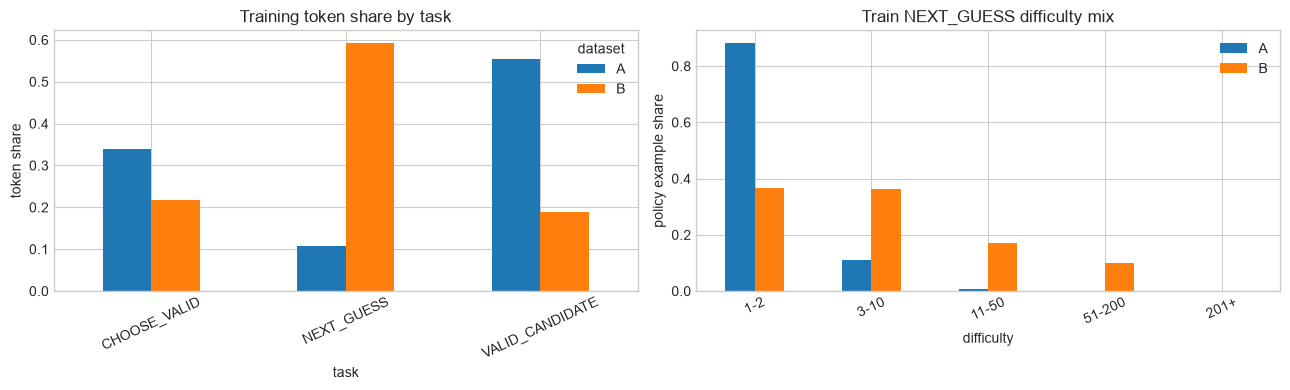

In [13]:
task_share_plot = (
    allocation.reset_index()
    .pivot(index="task", columns="dataset", values="token_share")
)

policy_difficulty_plot = pd.DataFrame({
    name: frame.loc[
        (frame["split"] == "train") & (frame["task"] == "NEXT_GUESS"),
        "difficulty",
    ].value_counts(normalize=True)
    for name, frame in {"A": dataset_a, "B": dataset_b}.items()
}).reindex(DIFFICULTY_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
task_share_plot.plot.bar(ax=axes[0], title="Training token share by task")
policy_difficulty_plot.plot.bar(ax=axes[1], title="Train NEXT_GUESS difficulty mix")
axes[0].set_ylabel("token share")
axes[1].set_ylabel("policy example share")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 14.15 Persist Dataset B

The files include provenance columns for analysis. Lab 15 should tokenize only `prompt` and `response`.

The branch-grouped test split contains only 21 rows. Treat it as a mechanical integrity split, not a headline metric. The reserved 19-game evaluation is the end-to-end test.

In [14]:
OUTPUT_COLUMNS = [
    "task", "split", "source", "opening", "answer", "turn",
    "candidate_count", "state_key", "prompt", "response",
]

B_PATHS = {}
for split in ["train", "dev", "test"]:
    path = GENERATED_DIR / f"wordle-part2-policy-{split}.jsonl"
    split_df = dataset_b.loc[
        dataset_b["split"] == split, OUTPUT_COLUMNS
    ].copy()
    split_df.to_json(path, orient="records", lines=True, force_ascii=False)
    B_PATHS[split] = path
    print(split, len(split_df), "->", path)

a_hashes_after = {split: sha256_file(path) for split, path in A_PATHS.items()}
assert a_hashes_after == a_hashes_before
print("Dataset A fingerprints unchanged.")

train 8768 -> ../data/generated/wordle-part2-policy-train.jsonl
dev 1135 -> ../data/generated/wordle-part2-policy-dev.jsonl
test 21 -> ../data/generated/wordle-part2-policy-test.jsonl
Dataset A fingerprints unchanged.


In [15]:
train_b = dataset_b.loc[dataset_b["split"] == "train"]
train_b_policy = train_b.loc[train_b["task"] == "NEXT_GUESS"]

manifest = {
    "version": 1,
    "generator": "Lab 14 Part II policy-focused dataset",
    "control_dataset": {
        "name": "Lab 06 v2 / Dataset A",
        "sha256": a_hashes_before,
    },
    "expert": "candidate-only maximum Shannon entropy",
    "representation": "unchanged Lab 06 prompts and responses",
    "policy_weighting": "complete solved canonical trajectories; reserved gameplay paths excluded",
    "missing_state_generation": {
        "openings": ALTERNATIVE_OPENINGS,
        "weighting": "one example per unique model-facing history",
        "early_rule": {
            "turn": 2,
            "minimum_candidate_count": MIN_EARLY_CANDIDATES,
        },
        "deep_rule": {
            "minimum_turn": MIN_DEEP_TURN,
            "minimum_candidate_count": MIN_DEEP_CANDIDATES,
        },
        "trajectory_outcomes": alternative_summary.to_dict(orient="records"),
    },
    "auxiliary_budget": "at most one auxiliary example per unique non-opening history",
    "split_policy": "stable hash of first guess and feedback branch; 88/11/1 train/dev/test",
    "reserved_gameplay_test_answers": sorted(FIXED_GAMEPLAY_TEST_ANSWERS),
    "reserved_path_train_overlap": evaluation_overlap,
    "counts": {
        split: int((dataset_b["split"] == split).sum())
        for split in ["train", "dev", "test"]
    },
    "train_task_counts": {
        task: int(count)
        for task, count in train_b["task"].value_counts().items()
    },
    "train_policy_metrics": {
        "example_share": float(len(train_b_policy) / len(train_b)),
        "token_share": float(
            train_b_policy["token_length"].sum() / train_b["token_length"].sum()
        ),
        "candidate_11_plus_rows": int(train_b_policy["candidate_count"].ge(11).sum()),
        "candidate_11_plus_unique_states": int(
            train_b_policy.loc[
                train_b_policy["candidate_count"].ge(11), "state_key"
            ].nunique()
        ),
        "candidate_51_plus_rows": int(train_b_policy["candidate_count"].ge(51).sum()),
        "candidate_51_plus_unique_states": int(
            train_b_policy.loc[
                train_b_policy["candidate_count"].ge(51), "state_key"
            ].nunique()
        ),
        "unique_states": int(train_b_policy["state_key"].nunique()),
    },
    "canonical_failures": canonical_failures,
    "ambiguous_prompt_count": int(
        dataset_b.groupby("prompt")["response"].nunique().gt(1).sum()
    ),
}

manifest_path = GENERATED_DIR / "wordle-part2-policy-manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print(manifest_path)
print(json.dumps(manifest, indent=2))

../data/generated/wordle-part2-policy-manifest.json
{
  "version": 1,
  "generator": "Lab 14 Part II policy-focused dataset",
  "control_dataset": {
    "name": "Lab 06 v2 / Dataset A",
    "sha256": {
      "train": "e54bb9cd2f17c2aef3ae0b6c835c987528525dac722a9b9e2076d4685e26dbf4",
      "dev": "e241f2e9918058a7f7653c977c8314e01b792a0af3069dffd7351882dc948a3a",
      "test": "986b15b8094d40ef24251ea4b10363ede6b202b3053c64f23e2a7e9496ee28cd"
    }
  },
  "expert": "candidate-only maximum Shannon entropy",
  "representation": "unchanged Lab 06 prompts and responses",
  "policy_weighting": "complete solved canonical trajectories; reserved gameplay paths excluded",
  "missing_state_generation": {
    "openings": [
      "STARE",
      "MOUND",
      "GLYPH",
      "FJORD"
    ],
    "weighting": "one example per unique model-facing history",
    "early_rule": {
      "turn": 2,
      "minimum_candidate_count": 11
    },
    "deep_rule": {
      "minimum_turn": 3,
      "minimum_candidate

## 14.16 Predictions for the controlled Lab 15 experiment

Dataset B is justified if the executed comparisons show:

1. policy examples and tokens dominate auxiliary supervision as a consequence of the state budget;
2. train contains substantial unique `NEXT_GUESS` state coverage at 11+ and 51+ candidates, reported separately from visitation-weighted rows;
3. auxiliary examples per state are capped while canonical policy visits retain trajectory weighting;
4. fixed gameplay test answers and every exact state on their canonical expert paths remain excluded from both train corpora;
5. prompts and targets remain mechanically valid and unambiguous.

Lab 15 should hold the base model, LoRA configuration, optimizer, learning rate, total optimizer steps or training-token budget, and gameplay evaluation constant. Both evaluations must begin with the same fixed `RAISE` turn so this experiment starts at turn 2. Equal epochs would be confounded because Dataset A and Dataset B contain different token counts.

The primary comparison tests the two-component redesign jointly. It can show that policy-focused dataset design helped, but it cannot assign the gain to one component. The `source` column preserves the boundary for two later ablations: Dataset B without alternative openings, and Dataset B with canonical policy visits deduplicated. Lab 22 is the right place to run them if the combined intervention works. The causal question is:

> Does policy allocation plus deliberately created high-uncertainty state coverage improve actual Wordle gameplay?

### Lab 15 metric hierarchy

The primary metric is **post-opening history-consistent non-repeated guess rate**. Count a model call as successful only when it returns a format-valid five-letter guess, does not repeat an earlier guess, and satisfies every prior feedback row. Divide by all model calls after the seeded `RAISE` turn across the held-out games.

Secondary metrics are fixed-opening solve rate, candidate-set reduction split by broad versus narrow states, and held-out `NEXT_GUESS` policy quality by turn and candidate-count bucket.

Format-valid output rate, repeat rate, generated top-10 guess share, frequent-teacher-target output, and auxiliary task accuracy are guardrails. They diagnose regressions but do not replace the primary metric.

# Lab 14 checkpoint

Record before training:

1. Dataset A fingerprints;
2. alternative-opening state counts and candidate distributions;
3. Dataset A versus B example and token allocation;
4. both train `NEXT_GUESS` turn-by-difficulty tables;
5. effective examples per state by task;
6. Dataset B split sizes and manifest;
7. the exact Lab 15 prediction.

Dataset A and Dataset B are now defined controls. Do not tune Dataset B after seeing Lab 15 results without naming the revision and rerunning the comparison.